### Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from hydra import compose, initialize
from pathlib import Path
from omegaconf import OmegaConf

initialize(config_path="../config", version_base="1.3")
cfg = compose(config_name="config")
print(OmegaConf.to_yaml(cfg))

sys.path.insert(0, str(cfg.paths.project_root))

from src.activation_recorder import MultiPromptActivations
from src.time_series_activations import MultiPromptTimeSeries
from src.phyid_decomposition import MultiPromptPhyID, PromptPhyID, PhyIDTimeSeries


paths:
  project_root: /home/p84400019/projects/consciousness-llms/IT-LLMs/
  model_path: ${model.company}/${model.model_family}/${model.model_size}/${model.it}/
  activation_method: ${time_series.node_type}/${time_series.node_activation}/${time_series.projection_method}/
  phyid_method: ${paths.activation_method}phyid_tau-${phyid.tau}/phyid_kind-${phyid.kind}/phyid_redundancy-${phyid.redundancy}/
  deactivation_method: deactivate_k_nodes_per_iteration-${deactivation_analysis.deactivate_k_nodes_per_iteration}/max_deactivated_nodes-${deactivation_analysis.max_deactivated_nodes}/n_randomised_runs-${deactivation_analysis.n_randomised_runs}/micro_batch_size-${deactivation_analysis.micro_batch_size}/reverse_kl-${deactivation_analysis.reverse_kl}/run_reverse_ranking-${deactivation_analysis.run_reverse_ranking}/noise_std-${deactivation_analysis.noise_std}/
  data_dir: ${paths.project_root}data/${paths.model_path}${generation.name}/
  data_activations_dir: ${paths.data_dir}activations/
  data_

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Time Series Loading

In [ ]:
data_activations_file = cfg.paths.data_activations_file
activations = MultiPromptActivations.load(file_path=data_activations_file)

MultiPromptActivations successfully loaded from '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/1B/instruct/subset/activations/multi_prompt_activations.pkl'.


In [ ]:
time_series = MultiPromptTimeSeries.from_activations(
    activations, 
    node_type=cfg.time_series.node_type,
    node_activation=cfg.time_series.node_activation,
    projection_method=cfg.time_series.projection_method, 
    exclude_shared_expert_moe=cfg.time_series.exclude_shared_expert_moe, 
)
time_series.plot(token_x=True, ticks_all_layers=True)#, plot_dir=cfg.paths.plot_time_series_dir)

#### Single Time Series

In [25]:
ts = time_series.prompts[10]
ts.plot_two_series(series_a=(14,8), series_b=(15,5), tokens=range(0,64), plot_dir=cfg.paths.plot_time_series_dir)

Two-series SVG saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/1B/instruct/subset/time_series/attention/attention_outputs/norm/


### PhyID Decomposition

In [2]:
compute_phyid = False
data_phyid_path = cfg.paths.data_phyid_dir

if compute_phyid:
    phyid_comp = MultiPromptPhyID.from_time_series(
        time_series,
        cfg.phyid.tau,
        cfg.phyid.kind,
        cfg.phyid.redundancy
    ) 
    phyid_comp.save(dir_path=data_phyid_path)
phyid = MultiPromptPhyID.load_average_prompt_phyid(dir_path=data_phyid_path)

FileNotFoundError: Average PromptPhyID file not found: /home/p84400019/projects/consciousness-llms/IT-LLMs/data/alibaba/qwen-3/4B/base/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/average.pkl

In [ ]:
phyid.__dict__.pop("syn_minus_red_duplets", None)
phyid.syn_minus_red_duplets

[(4, 3),
 (3, 1),
 (5, 26),
 (9, 7),
 (7, 23),
 (7, 9),
 (7, 30),
 (8, 29),
 (7, 17),
 (7, 29),
 (7, 11),
 (8, 23),
 (6, 23),
 (6, 20),
 (8, 22),
 (8, 3),
 (6, 27),
 (10, 22),
 (7, 6),
 (9, 6),
 (8, 5),
 (7, 16),
 (6, 22),
 (7, 0),
 (10, 15),
 (9, 4),
 (5, 29),
 (8, 4),
 (7, 15),
 (5, 30),
 (8, 28),
 (7, 25),
 (7, 22),
 (7, 7),
 (10, 20),
 (8, 6),
 (10, 14),
 (8, 1),
 (7, 1),
 (10, 9),
 (7, 24),
 (7, 26),
 (7, 20),
 (9, 25),
 (10, 30),
 (6, 17),
 (8, 11),
 (10, 13),
 (6, 21),
 (8, 10),
 (9, 15),
 (7, 27),
 (6, 7),
 (4, 22),
 (10, 11),
 (6, 1),
 (5, 27),
 (7, 18),
 (10, 10),
 (9, 22),
 (8, 21),
 (8, 2),
 (10, 24),
 (6, 29),
 (7, 31),
 (2, 13),
 (7, 3),
 (5, 25),
 (5, 18),
 (8, 20),
 (7, 19),
 (7, 28),
 (10, 12),
 (6, 28),
 (8, 30),
 (9, 27),
 (4, 17),
 (7, 14),
 (11, 7),
 (7, 13),
 (0, 0),
 (8, 0),
 (6, 18),
 (2, 0),
 (9, 21),
 (10, 23),
 (10, 21),
 (9, 26),
 (8, 14),
 (5, 23),
 (1, 10),
 (4, 15),
 (9, 24),
 (9, 13),
 (10, 26),
 (9, 10),
 (8, 9),
 (9, 5),
 (8, 7),
 (8, 31),
 (5, 28),
 (

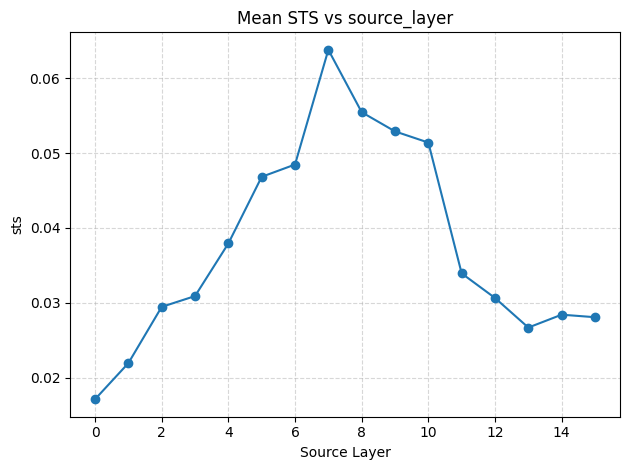

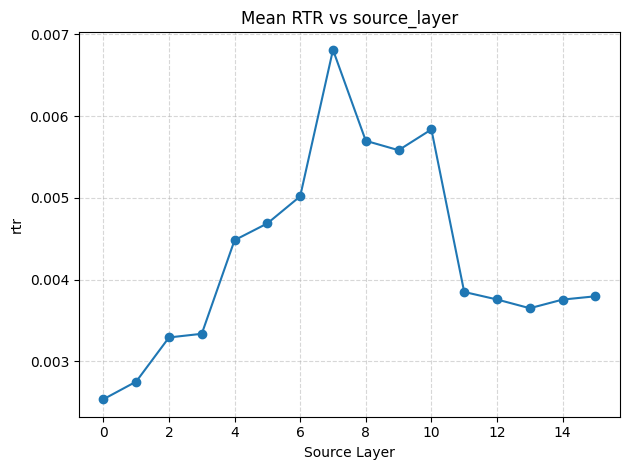

PNG saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/1B/instruct/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/syn_minus_red_rank/rank_plot.png
SVG saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/1B/instruct/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/syn_minus_red_rank/rank_plot.svg


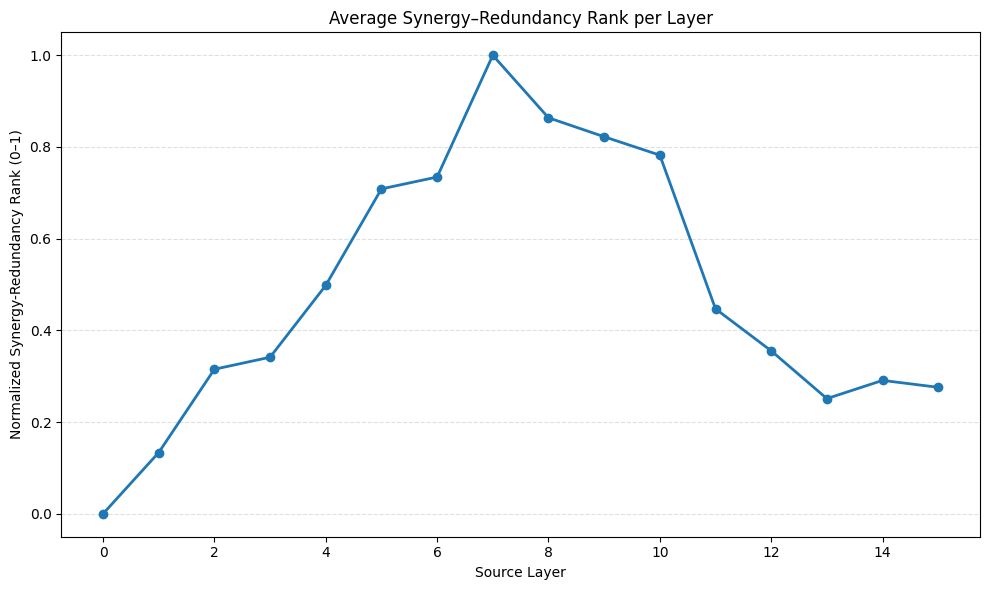

Synergy–Redundancy Rank of N03-L08: 497
Synergy–Redundancy Rank of N03-L08: 497


In [ ]:
# phyid.node_heatmap(atom='sts', plot_dir=cfg.paths.plot_phyid_dir)
# phyid.node_heatmap(atom='rtr', plot_dir=cfg.paths.plot_phyid_dir)
phyid.plot_mean_along('sts', 'source_layer')#, plot_dir=cfg.paths.plot_phyid_dir)
phyid.plot_mean_along('rtr', 'source_layer')#, plot_dir=cfg.paths.plot_phyid_dir)
node_ranking = phyid.syn_minus_red_rank
phyid.plot_syn_minus_red_rank_per_node(node_ranking, save_svg=True, figsize=(12, 6), plot_dir=cfg.paths.plot_phyid_dir)
phyid.plot_syn_minus_red_rank_per_layer(node_ranking)
print(f"Synergy–Redundancy Rank of N03-L08: {node_ranking.sel(source_node=3, source_layer=8).values}")
print(f"Synergy–Redundancy Rank of N03-L08: {node_ranking.sel(source_node=3, source_layer=8).values}")

In [7]:
phyid.__dict__.pop("syn_minus_red_rank", None)
phyid.syn_minus_red_rank
phyid.plot_synergy_rank_heatmap()

AttributeError: 'PromptPhyID' object has no attribute 'plot_synergy_rank_heatmap'

In [8]:
node_ranking = phyid.syn_minus_red_rank
phyid.plot_syn_minus_red_rank_per_node(node_ranking, plot_dir=cfg.paths.plot_phyid_dir)
phyid.plot_syn_minus_red_rank_per_layer(node_ranking, plot_dir=cfg.paths.plot_phyid_dir)

PNG saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/1B/instruct/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/syn_minus_red_rank/rank_plot.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/1B/instruct/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/syn_minus_red_rank/avg_synergy_score_per_layer.png


In [ ]:
plot_dir = cfg.paths.plot_phyid_dir

phyid.node_heatmap(atom='sts', plot_dir=plot_dir)
phyid.plot_mean_along('sts', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('syn_minus_red', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('sts_normalized', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('rtr', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('mutual_information', varying_dim='source_layer', plot_dir=plot_dir)

Heatmap saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/node_heatmap/sts/heatmap.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/sts/source_layer.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/syn_minus_red/source_layer.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/sts_normalized/source_layer.png
Plot saved to /home/p84400019/projects/c

### Graph Theoretical Analysis

In [ ]:
from src.graph_theoretical_analysis import PromptGraphTheoreticalAnalysis

graph_theoretical = PromptGraphTheoreticalAnalysis.from_phyid_data(prompt_phyid=phyid)

In [ ]:
# graph_theoretical.plot_atom_graph(atom='sts')
sge = graph_theoretical.global_efficiency(atom='sts')
smo = graph_theoretical.modularity(atom='sts')
rge = graph_theoretical.global_efficiency(atom='rtr')
rmo = graph_theoretical.modularity(atom='rtr')
print(f"STS Global Efficiency: {sge}, STS Modularity: {smo}")
print(f"RTR Global Efficiency: {rge}, RTR Modularity: {rmo}")

STS Global Efficiency: 0.07378549225262356, STS Modularity: 0.034103109771126294
RTR Global Efficiency: 0.011879988444945878, RTR Modularity: 0.10393579895766247


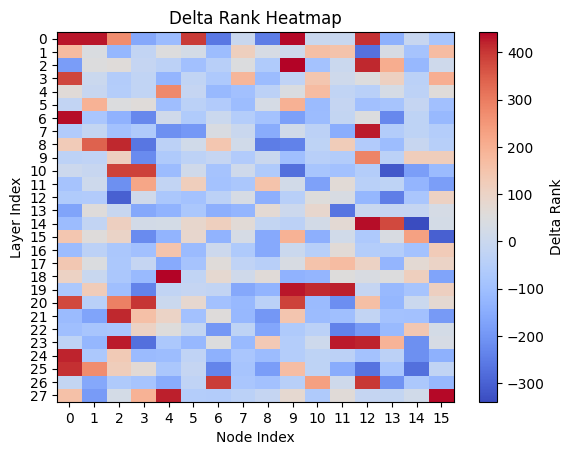

Gateways and Broadcasters: {'nodes': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 

In [ ]:
gb = graph_theoretical.gateways_and_broadcasters()
print(f"Gateways and Broadcasters: {gb}")